In [1]:
# =====================================================
# PROJECT : AI Powered Vehicle Valuation System
#
# NOTEBOOK :
# 08_Model_Explainability.ipynb
#
# PURPOSE :
# Explain the trained model and prepare
# production-ready artifacts.
#
# AUTHOR :
# Srivignesh
# =====================================================

In [2]:
# =====================================================
# Import Required Libraries
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

In [3]:
# =====================================================
# Load Feature Engineered Dataset
# =====================================================

df = pd.read_csv("../data/vehicle_feature_engineered.csv")

print(df.shape)

df.head()

(37006, 15)


,oem,model,variant,myear,fuel,transmission,km,body,owner_type,City,state,listed_price,car_age,premium_brand,price_category
0,maruti,maruti wagon r,lxi cng,2016,cng,manual,69162.0,hatchback,first,lucknow,uttar pradesh,370000.0,10,0,Mid Range
1,maruti,maruti celerio,green vxi,2015,cng,manual,45864.0,hatchback,first,mumbai,maharashtra,365000.0,11,0,Mid Range
2,honda,honda amaze,s plus i-vtec,2015,cng,manual,81506.0,sedan,second,new delhi,delhi,421000.0,11,0,Mid Range
3,maruti,maruti wagon r,lxi cng,2013,cng,manual,115893.0,hatchback,second,new delhi,delhi,240000.0,13,0,Budget
4,maruti,maruti ertiga,vxi cng,2022,cng,manual,18900.0,muv,first,mumbai,maharashtra,1175000.0,4,0,Premium


In [4]:
# =====================================================
# Define Features and Target
# =====================================================

X = df.drop(

    columns=[

        "listed_price",

        "price_category"

    ]

)

y = df["listed_price"]

In [5]:
# =====================================================
# STEP 5.1 : Split Dataset
# =====================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (29604, 13)
Testing Shape : (7402, 13)


In [6]:
# =====================================================
# Define Categorical and Numerical Features
# =====================================================

categorical_features = [

    "oem",

    "model",

    "variant",

    "fuel",

    "transmission",

    "body",

    "owner_type",

    "City",

    "state"

]

numerical_features = [

    "km",

    "car_age",

    "premium_brand"

]

In [7]:
# =====================================================
# Create Column Transformer
# =====================================================

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(

    transformers=[

        (

            "categorical",

            OneHotEncoder(

                handle_unknown="ignore"

            ),

            categorical_features

        ),

        (

            "numerical",

            "passthrough",

            numerical_features

        )

    ]

)

In [8]:
# =====================================================
# Create Production Pipeline
# =====================================================

from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

production_model = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "regressor",

            XGBRegressor(

                objective="reg:squarederror",

                n_estimators=300,

                learning_rate=0.05,

                max_depth=8,

                random_state=42

            )

        )

    ]

)

In [9]:
# =====================================================
# Train Production Model
# =====================================================

production_model.fit(

    X_train,

    y_train

)

print()

print("Production Model Trained Successfully!")

print()

print("Model Version : v1.0")


Production Model Trained Successfully!

Model Version : v1.0


In [10]:
# =====================================================
# Generate Predictions
# =====================================================

y_pred = production_model.predict(

    X_test

)

print("Predictions Generated Successfully!")

print()

print("Total Predictions :", len(y_pred))

Predictions Generated Successfully!

Total Predictions : 7402


In [11]:
# =====================================================
# Evaluate Production Model
# =====================================================

import numpy as np

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score

)

mae = mean_absolute_error(

    y_test,

    y_pred

)

mse = mean_squared_error(

    y_test,

    y_pred

)

rmse = np.sqrt(mse)

r2 = r2_score(

    y_test,

    y_pred

)

print("="*60)

print("PRODUCTION MODEL PERFORMANCE")

print("="*60)

print()

print(f"MAE  : {mae:,.2f}")

print(f"RMSE : {rmse:,.2f}")

print(f"R²   : {r2:.4f}")

PRODUCTION MODEL PERFORMANCE

MAE  : 88,889.34
RMSE : 153,777.86
R²   : 0.9481


In [12]:
#Notebook 06 was used for experimentation and baseline evaluation. Notebook 08 trains the finalized production configuration to generate deployment artifacts such as the versioned model, feature importance analysis, model metrics, and explainability reports. This separation ensures reproducibility and follows a standard ML project workflow.

In [13]:
# =====================================================
# Extract Trained XGBoost Model
# =====================================================

xgb_model = baseline_model.named_steps["regressor"]

NameError: name 'baseline_model' is not defined

In [14]:
# =====================================================
# STEP 6.1 : Extract Trained XGBoost Model
# =====================================================

xgb_model = production_model.named_steps["regressor"]

print("XGBoost Model Extracted Successfully!")

XGBoost Model Extracted Successfully!


In [15]:
# =====================================================
# STEP 6.2 : Extract Preprocessor
# =====================================================

preprocessor = production_model.named_steps["preprocessor"]

print("Preprocessor Extracted Successfully!")

Preprocessor Extracted Successfully!


In [16]:
# =====================================================
# STEP 6.3 : Get Encoded Feature Names
# =====================================================

feature_names = preprocessor.get_feature_names_out()

print("Total Features :", len(feature_names))

Total Features : 4069


In [17]:
# =====================================================
# STEP 6.4 : Create Feature Importance DataFrame
# =====================================================

import pandas as pd

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": xgb_model.feature_importances_

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

importance_df.head(20)

,Feature,Importance
4068,numerical__premium_brand,0.314333
152,categorical__model_jeep compass,0.072836
3461,categorical__body_hatchback,0.043390
3468,categorical__body_suv,0.034901
17,categorical__oem_jeep,0.019226
349,categorical__model_toyota innova crysta,0.015780
18,categorical__oem_kia,0.015302
3457,categorical__transmission_automatic,0.010139
4067,numerical__car_age,0.010042
102,categorical__model_ford endeavour,0.009338


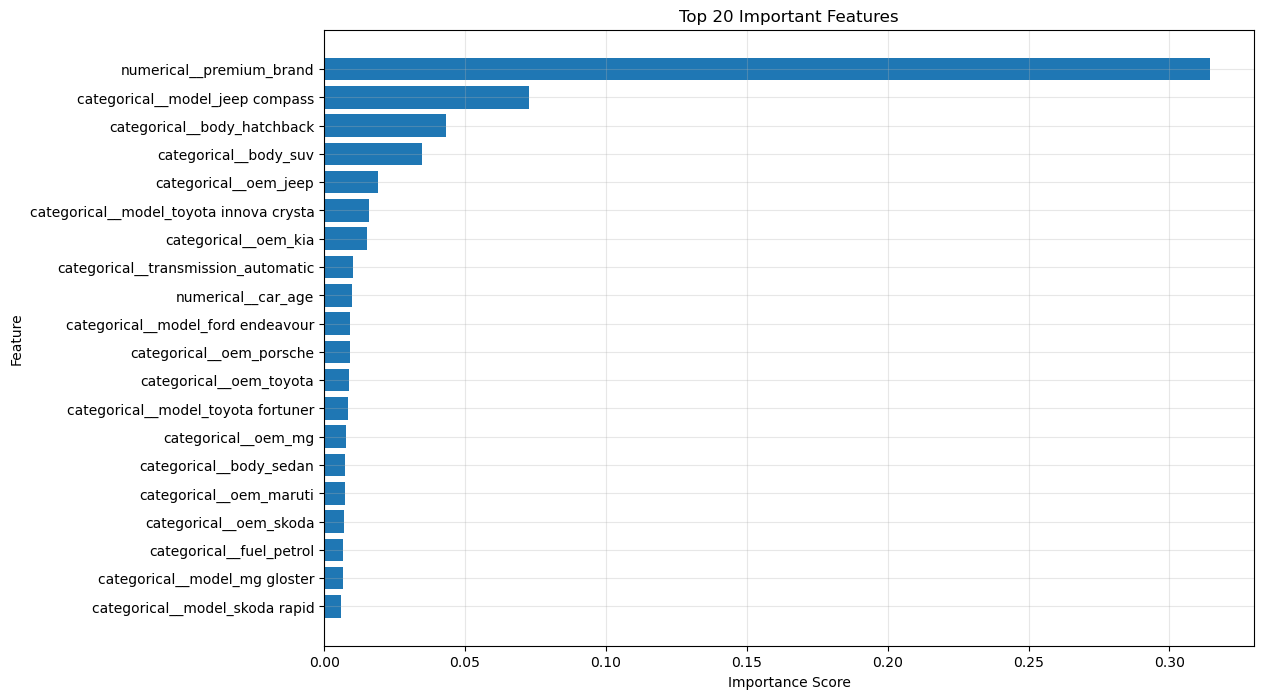

In [18]:
# =====================================================
# STEP 6.5 : Plot Top 20 Important Features
# =====================================================

import matplotlib.pyplot as plt

top_features = importance_df.head(20)

plt.figure(figsize=(12,8))

plt.barh(

    top_features["Feature"],

    top_features["Importance"]

)

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.grid(alpha=0.3)

plt.show()


In [19]:
import joblib

joblib.dump(
    production_model,
    "../models/vehicle_price_model_v1.pkl"
)

print("Model Saved Successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '../models/vehicle_price_model_v1.pkl'

In [20]:
import os

print(os.getcwd())

/home/sagemaker-user/vehicle_valuation/notebook


In [21]:
# =====================================================
# Create Project Folders
# =====================================================

import os

project_path = "/home/sagemaker-user/vehicle_valuation"

folders = [
    "models",
    "backend",
    "frontend",
    "reports"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [22]:
import os

print(os.listdir("/home/sagemaker-user/vehicle_valuation"))

['data', 'notebook', '.ipynb_checkpoints', 'frontend', 'reports', 'README.md', 'backend', 'models']


In [23]:
# =====================================================
# Save Production Model v1
# =====================================================

import joblib

model_path = "/home/sagemaker-user/vehicle_valuation/models/vehicle_price_model_v1.pkl"

joblib.dump(
    production_model,
    model_path
)

print("✅ Production Model Saved Successfully!")

print("Location:", model_path)

✅ Production Model Saved Successfully!
Location: /home/sagemaker-user/vehicle_valuation/models/vehicle_price_model_v1.pkl


In [24]:
import os

print(os.listdir("/home/sagemaker-user/vehicle_valuation/models"))

['vehicle_price_model_v1.pkl']
